## CONTEXTE:
- Dans le secteur bancaire, il est crucial d'identifier les clients à risque pour minimiser les pertes liées aux prêts non remboursés. Ce projet vise à créer un modèle de classification qui prédit la probabilité qu'un client fasse défaut
- Lien Dataset: https://www.kaggle.com/datasets/itsmesunil/bank-loan-modelling



<a id='I-Exploration des Données'></a>
<h1 style="color:white;text-transform:uppercase;text-align:center;background:indigo;padding: 2% 20% "> I-Exploration des Données</h1>


> Dans cette section du rapport, nous allons charger les données, vérifier leurs proprietés, puis les nettoyer.

### Propriété générale

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel('Bank_Personal_Loan_Modelling.xlsx')

C:\Users\DIFFO\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df

,ID,Age,Expérience,Revenus,Code postal,Famille,CCAvg,Education,Pret Immobilier,Prêt Personnel,Compte de titres,Compte CD,En ligne,Carte de credit
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Affichage des informations de base
print("Dimensions du dataset:", df.shape)
print("\nInformations sur les données:")
print(df.info())





Dimensions du dataset: (5000, 14)

Informations sur les données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                5000 non-null   int64  
 1   Age               5000 non-null   int64  
 2   Expérience        5000 non-null   int64  
 3   Revenus           5000 non-null   int64  
 4   Code postal       5000 non-null   int64  
 5   Famille           5000 non-null   int64  
 6   CCAvg             5000 non-null   float64
 7   Education         5000 non-null   int64  
 8   Pret Immobilier   5000 non-null   int64  
 9   Prêt Personnel    5000 non-null   int64  
 10  Compte de titres  5000 non-null   int64  
 11  Compte CD         5000 non-null   int64  
 12  En ligne          5000 non-null   int64  
 13  Carte de credit   5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB
None


In [4]:
print("\nStatistiques descriptives:")
df.describe()


Statistiques descriptives:


,ID,Age,Expérience,Revenus,Code postal,Famille,CCAvg,Education,Pret Immobilier,Prêt Personnel,Compte de titres,Compte CD,En ligne,Carte de credit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937913,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747666,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [5]:
print("\nValeurs manquantes:")
df.isnull().sum()


Valeurs manquantes:


ID                  0
Age                 0
Expérience          0
Revenus             0
Code postal         0
Famille             0
CCAvg               0
Education           0
Pret Immobilier     0
Prêt Personnel      0
Compte de titres    0
Compte CD           0
En ligne            0
Carte de credit     0
dtype: int64

In [6]:
print("Doublons")
df.duplicated().sum()

Doublons


0

<a id='Analyse exploratoire des données(EDA)'></a>
<h2 style="color:white;text-transform:uppercase;text-align:center;background:indigo;padding: 1% 10% "> II-Analyse exploratoire des données(EDA)</h2>


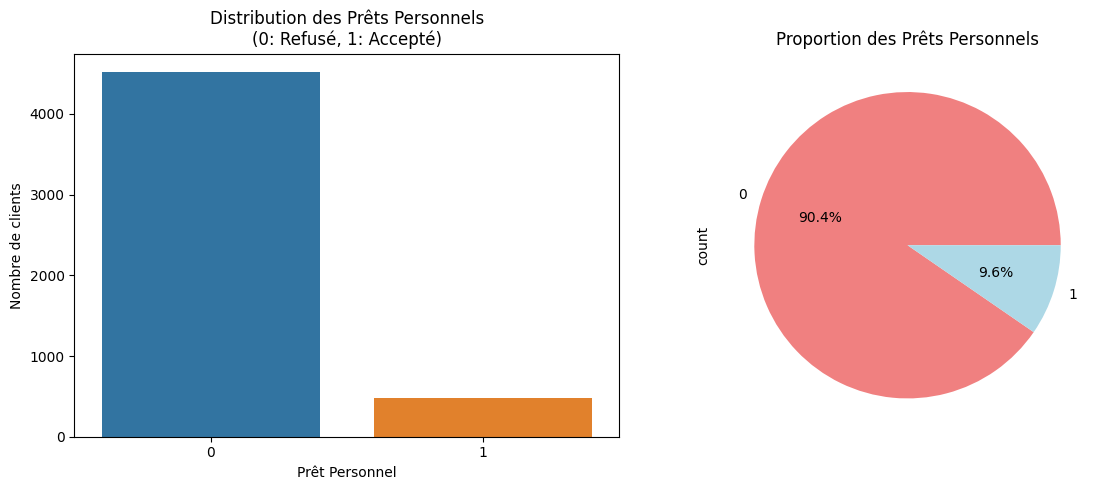

C:\Users\DIFFO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DIFFO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DIFFO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DIFFO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

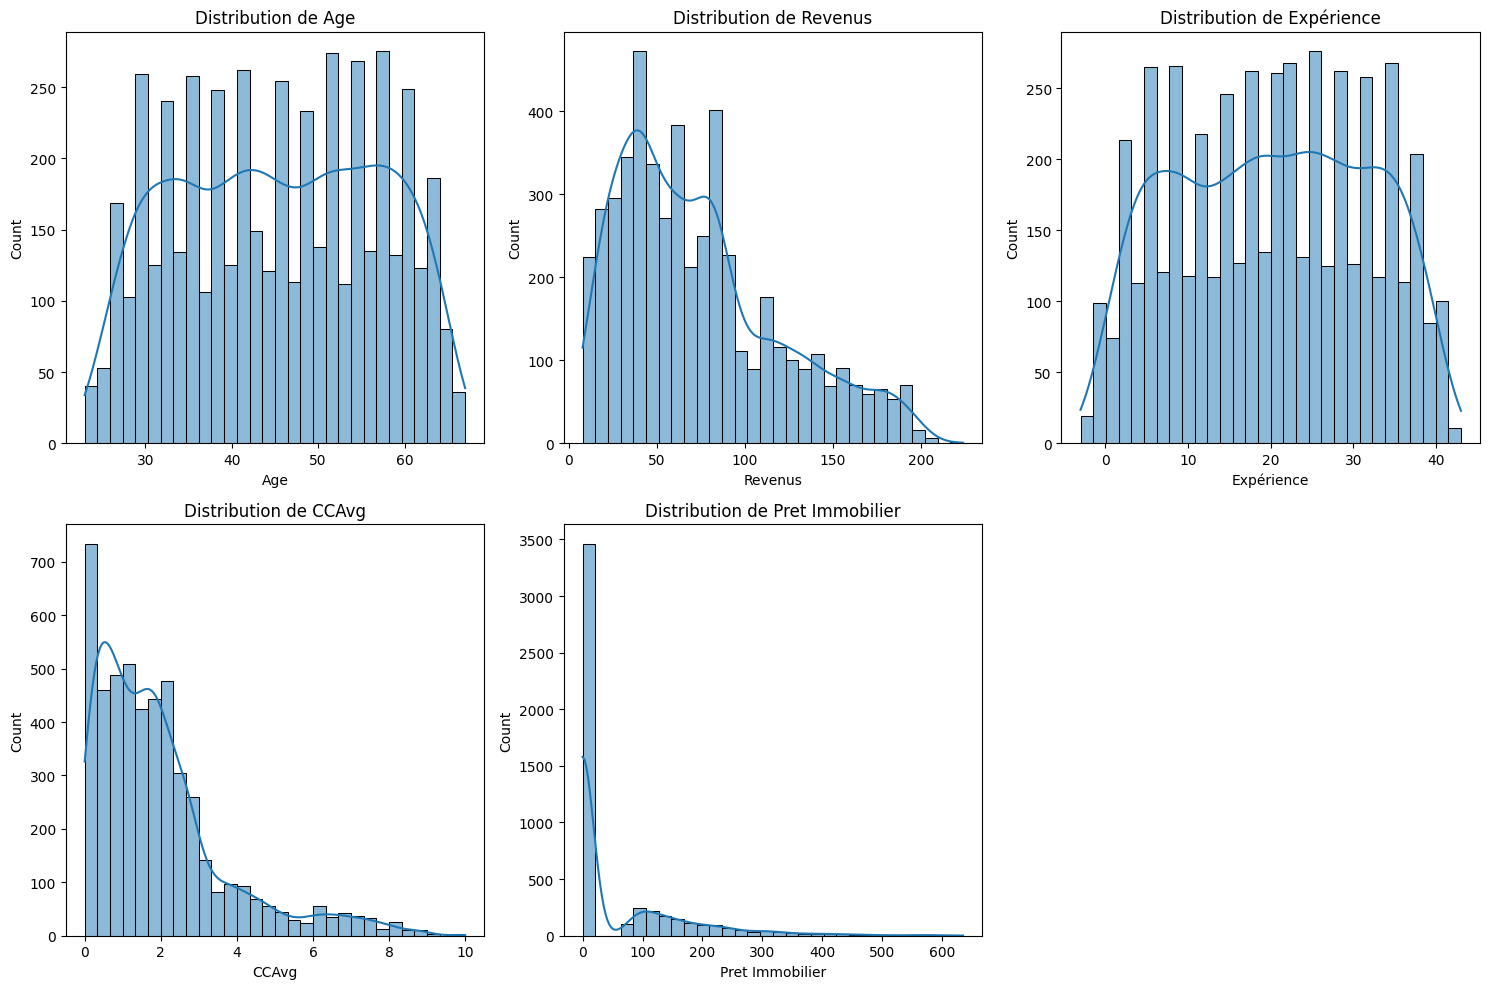

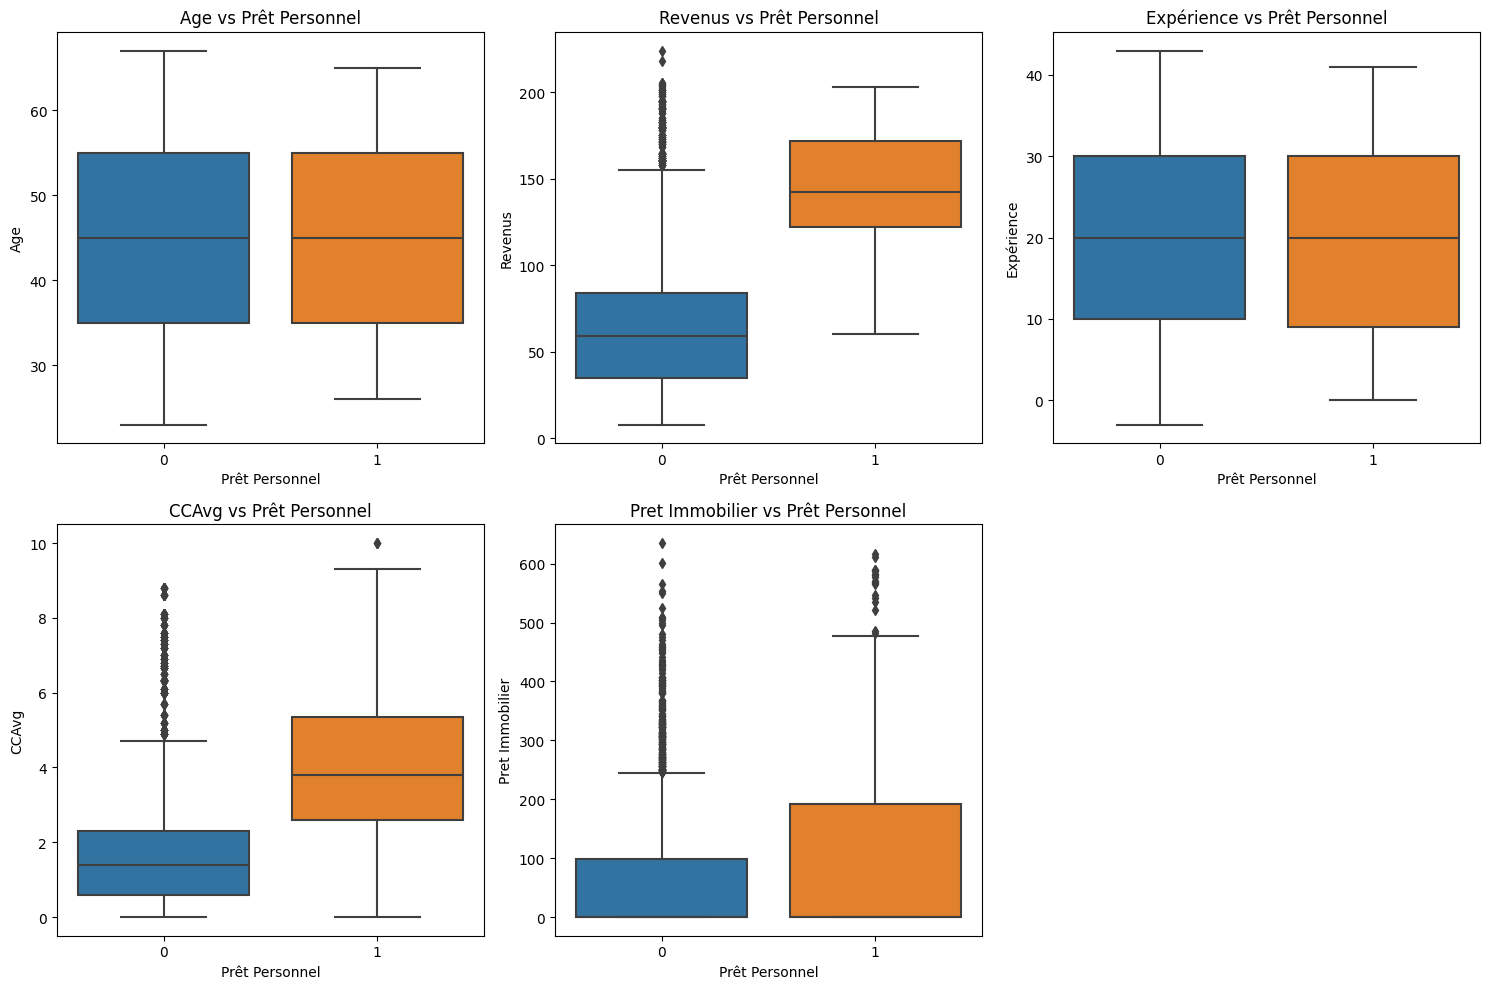

In [7]:
# Distribution de la variable cible (Prêt Personnel)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Prêt Personnel', data=df)
plt.title('Distribution des Prêts Personnels\n(0: Refusé, 1: Accepté)')
plt.xlabel('Prêt Personnel')
plt.ylabel('Nombre de clients')

plt.subplot(1, 2, 2)
df['Prêt Personnel'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
plt.title('Proportion des Prêts Personnels')

plt.tight_layout()
plt.show()

# Distribution des variables numériques importantes
numeric_features = ['Age', 'Revenus', 'Expérience', 'CCAvg', 'Pret Immobilier']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution de {feature}')
plt.tight_layout()
plt.show()

# Analyse des variables par rapport à la cible
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Prêt Personnel', y=feature, data=df)
    plt.title(f'{feature} vs Prêt Personnel')
plt.tight_layout()
plt.show()


## Influence des Variables sur le risque de Défaut(Statut du pret)

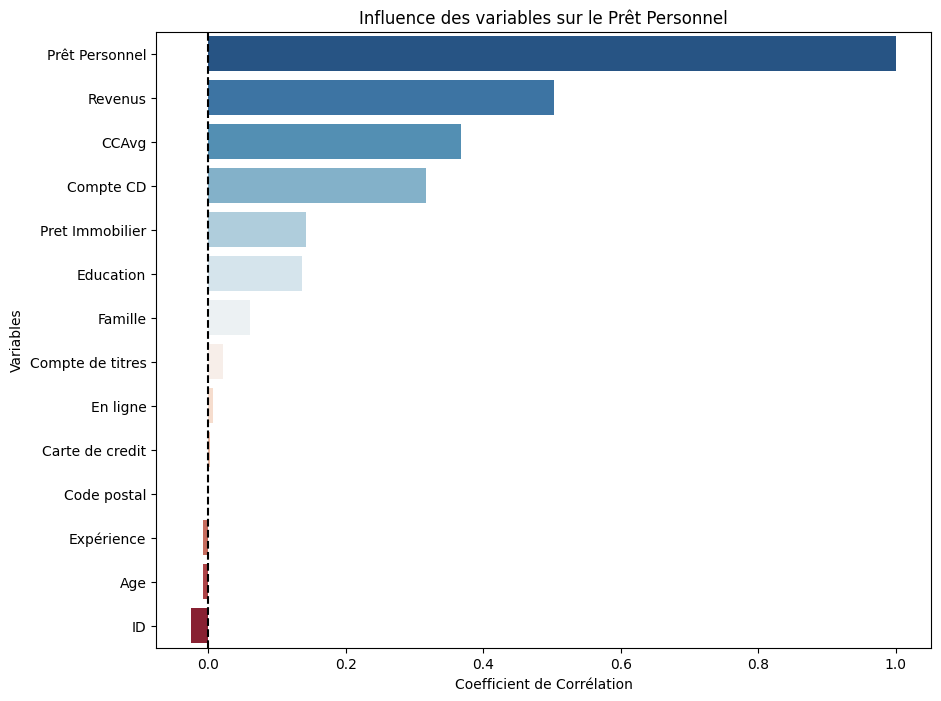

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# On calcule la corrélation uniquement par rapport à la cible (Statut du prêt)
# On trie du plus corrélé au moins corrélé
correlations_cible = df.corr()['Prêt Personnel'].sort_values(ascending=False)

# Affichage graphique pour une lecture immédiate
plt.figure(figsize=(10, 8))
sns.barplot(x=correlations_cible.values, y=correlations_cible.index, palette='RdBu_r')

plt.title("Influence des variables sur le Prêt Personnel")
plt.xlabel("Coefficient de Corrélation")
plt.ylabel("Variables")
plt.axvline(x=0, color='black', linestyle='--') # Ligne de neutralité
plt.show()

# Feature Engineering

## Suppression des variable qui on une corrélation très faible par rapport au statut du pret 

In [11]:
# 1. Sélection des variables utiles (on enlève les faibles corrélations)
X = df.drop(['Prêt Personnel', 'ID', 'Age', 'Expérience','Code postal','Carte de credit','En ligne','Compte de titres'], axis=1)
y = df['Prêt Personnel']

## Split 80/20

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## La Gestion du déséquilibre 

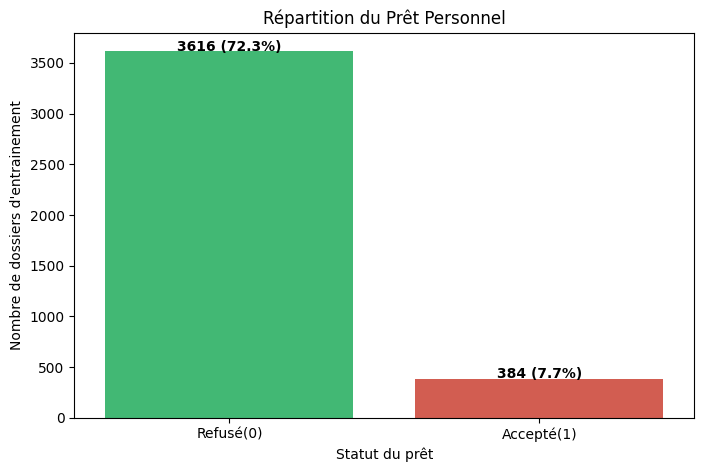

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul du nombre de cas pour chaque catégorie
counts = y_train.value_counts()

# 2. Création du graphique
plt.figure(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, palette=['#2ecc71', '#e74c3c'])

plt.title("Répartition du Prêt Personnel")
plt.xlabel("Statut du prêt")
plt.ylabel("Nombre de dossiers d'entrainement")
plt.xticks(ticks=[0, 1], labels=['Refusé(0)', 'Accepté(1)'])

# Ajouter les pourcentages sur les barres
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, f"{v} ({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

plt.show()

SMOTE ((Synthetic Minority Over-sampling Technique)) pour équilibrer le Train

In [16]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Données équilibrées et prêtes pour l'entraînement !")

Données équilibrées et prêtes pour l'entraînement !


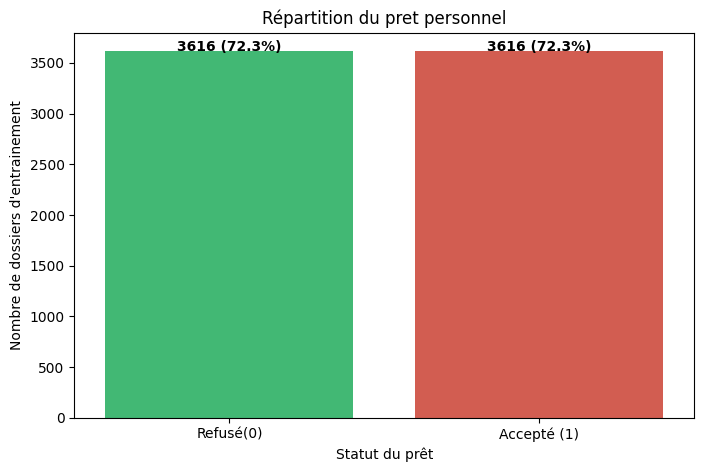

In [17]:
# 1. Calcul du nombre de cas pour chaque catégorie
counts = y_train_res.value_counts()

# 2. Création du graphique
plt.figure(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, palette=['#2ecc71', '#e74c3c'])

plt.title("Répartition du pret personnel")
plt.xlabel("Statut du prêt")
plt.ylabel("Nombre de dossiers d'entrainement")
plt.xticks(ticks=[0, 1], labels=['Refusé(0)', 'Accepté (1)'])

# Ajouter les pourcentages sur les barres
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, f"{v} ({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

plt.show()

In [19]:
y_train_res.value_counts(normalize=True)

Prêt Personnel
0    0.5
1    0.5
Name: proportion, dtype: float64

## Modélisation 

### Model de base

#### Regression logistique

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Création du modèle
log_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entraînement sur les données équilibrées (SMOTE)
log_model.fit(X_train_res, y_train_res)

# 3. Prédiction sur les données de TEST (celles que le modèle n'a jamais vues)
y_pred_log = log_model.predict(X_test)

# 4. Évaluation
print("--- Résultats de la Régression Logistique ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log):.2%}")
print("\nMatrice de Confusion :")
print(confusion_matrix(y_test, y_pred_log))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_log))

--- Résultats de la Régression Logistique ---
Accuracy Score: 86.50%

Matrice de Confusion :
[[774 130]
 [  5  91]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       0.99      0.86      0.92       904
           1       0.41      0.95      0.57        96

    accuracy                           0.86      1000
   macro avg       0.70      0.90      0.75      1000
weighted avg       0.94      0.86      0.89      1000



#### Naive Bayes 

In [21]:
from sklearn.naive_bayes import GaussianNB

# 1. Création et entraînement
nb_model = GaussianNB()
nb_model.fit(X_train_res, y_train_res)

# 2. Prédiction
y_pred_nb = nb_model.predict(X_test)

# 3. Évaluation
print("--- Résultats de Naive Bayes ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_nb):.2%}")
print("\nMatrice de Confusion :")
print(confusion_matrix(y_test, y_pred_nb))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_nb))

--- Résultats de Naive Bayes ---
Accuracy Score: 84.80%

Matrice de Confusion :
[[766 138]
 [ 14  82]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       904
           1       0.37      0.85      0.52        96

    accuracy                           0.85      1000
   macro avg       0.68      0.85      0.71      1000
weighted avg       0.92      0.85      0.87      1000



#### Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

# 1. Création du modèle (100 arbres par défaut)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entraînement sur les données SMOTE
rf_model.fit(X_train_res, y_train_res)

# 3. Prédiction
y_pred_rf = rf_model.predict(X_test)

# 4. Évaluation
print("--- Résultats de Random Forest ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.2%}")
print("\nMatrice de Confusion :")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_rf))

--- Résultats de Random Forest ---
Accuracy Score: 97.30%

Matrice de Confusion :
[[879  25]
 [  2  94]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       904
           1       0.79      0.98      0.87        96

    accuracy                           0.97      1000
   macro avg       0.89      0.98      0.93      1000
weighted avg       0.98      0.97      0.97      1000



## XGBOOST

In [23]:
from xgboost import XGBClassifier

# 1. Création du modèle
# On utilise scale_pos_weight si on n'avait pas fait de SMOTE, 
# mais comme on a X_train_res, on le lance normalement.
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# 2. Entraînement
xgb_model.fit(X_train_res, y_train_res)

# 3. Prédiction
y_pred_xgb = xgb_model.predict(X_test)

# 4. Évaluation
print("--- Résultats de XGBoost ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_xgb):.2%}")
print("\nMatrice de Confusion :")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_xgb))

--- Résultats de XGBoost ---
Accuracy Score: 96.70%

Matrice de Confusion :
[[873  31]
 [  2  94]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       904
           1       0.75      0.98      0.85        96

    accuracy                           0.97      1000
   macro avg       0.87      0.97      0.92      1000
weighted avg       0.97      0.97      0.97      1000



### Le choix final est le model  Random forest Car il a un meilleur accuracy : 97.30% , et  prédit moins les faux positifs (25)

### La touche finale : L'importance des variables
#### Maintenant que nous avons le modèle champion, la banque va  demander : "Pourquoi ce client a-t-il été refusé ?". 
#### Pour répondre, nous allons afficher les variables qui ont le plus compté pour les décisions du Random Forest.

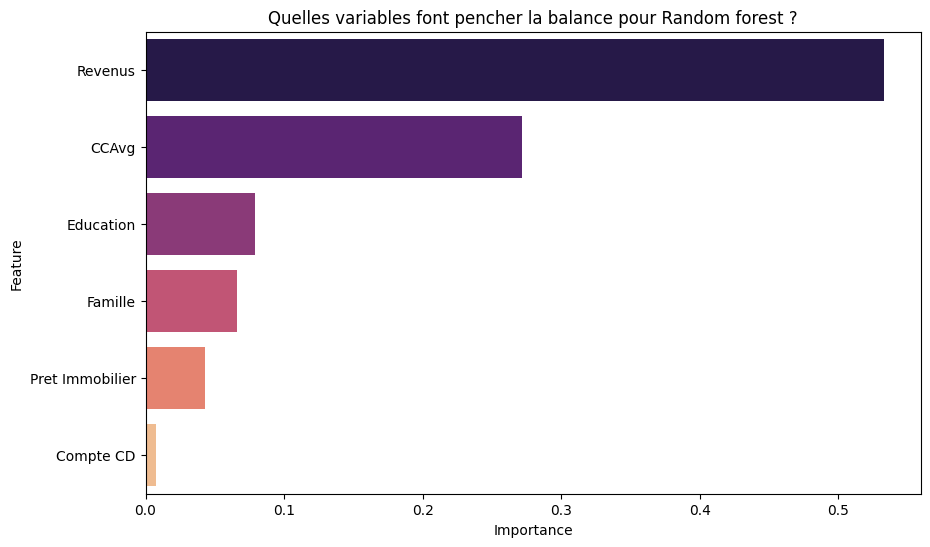

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Récupérer l'importance des variables
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. Graphique
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title("Quelles variables font pencher la balance pour Random forest ?")
plt.show()

### Allons plus loin : La simulation d'un client

In [40]:
import pandas as pd

# 1. On crée le client avec les mêmes colonnes et types que X
client_test = pd.DataFrame(0, index=[0], columns=X.columns)

# 2. On remplit les caractéristiques (Modifie ces valeurs pour tester !)
client_test['Revenus'] = 100
client_test['CCAvg'] = 2  # 1 pour A, 2 pour B, etc.
client_test['Education'] = 4.8
client_test['Famille'] = 2
client_test['Pret Immobilier'] = 0 # Il n'est pas propriétaire
client_test['Compte CD'] = 0   # Prêt pour projet pro

# --- ÉTAPE CRUCIALE : On s'assure que tout est numérique ---
client_test = client_test.apply(pd.to_numeric)

# 3. Prédiction
prediction =  rf_model.predict(client_test)
probabilite =  rf_model.predict_proba(client_test)

# 4. Affichage
print("=== RÉSULTAT DU SIMULATEUR DE CRÉDIT ===")
if prediction[0] == 0:
    print(f"Verdict : PAS DE défaut ✅")
    print(f"Confiance du modèle : {probabilite[0][0]:.2%}")
else:
    print(f"Verdict : défaut sur le pret ❌")
    print(f"Risque de défaut estimé : {probabilite[0][1]:.2%}")

=== RÉSULTAT DU SIMULATEUR DE CRÉDIT ===
Verdict : PAS DE défaut ✅
Confiance du modèle : 87.00%
